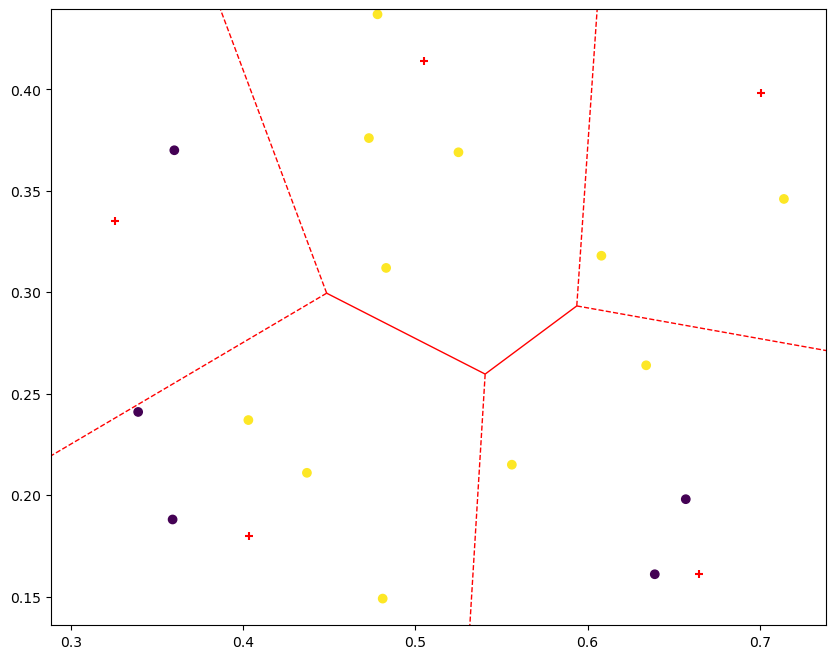

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d


class LVQ:
    def __init__(self,prototypes_pre_class,learning_rate=0.1,max_iter=100):
        """
        LVQ算法
        参数:
        prototypes_pre_class: 每个类别的原型向量个数(一个字典)
        learning_rate: 学习率
        max_iter: 最大迭代次数
        """
        self.prototypes_pre_class = prototypes_pre_class
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.p = None # 原型向量
        self.p_label = None # 原型向量标签

    def calculate_distance(self,x,p):
        """计算样本点与原型向量之间的欧氏距离"""
        return np.sqrt(np.sum((x - p)**2))
    
    def find_closest_centroid(self,distances):
        """返回最近的原型向量索引"""
        return np.argmin(distances)
    
    def fit(self,X,y):
        """训练"""
        # 初始化原型向量
        labels = np.unique(y)
        self.p = np.empty((0, X.shape[1]))
        self.p_label = np.array([])
        for label in labels:
            samples = X[y == label]
            idx = np.random.choice(len(samples),self.prototypes_pre_class[label],replace=False) 
            self.p = np.vstack((self.p, samples[idx])) # 纵向拼接
            self.p_label = np.hstack((self.p_label, label*np.ones(self.prototypes_pre_class[label]))) # 横向拼接
        # 迭代训练
        for i in range(self.max_iter):
            # 随机选取样本点
            idx = np.random.choice(len(X),1,replace=False)
            sample = X[idx[0]]
            label = y[idx]
            # 计算样本点与原型向量之间的距离
            distances = np.array([self.calculate_distance(sample,p) for p in self.p])
            # 找到最近的原型向量
            clostest_p_index = self.find_closest_centroid(distances)
            # 更新原型向量
            self.p[clostest_p_index] += self.learning_rate*(sample - self.p[clostest_p_index])
    
    
if __name__ == '__main__':
     # 加载数据
    data = np.loadtxt('../Data/4.0.csv',dtype = float,delimiter = ',')
    # 第9-21个样本标签为0，其他为1
    y = np.ones(len(data))
    y[8:21] = 0
    # 每个类的原型向量个数
    prototypes_pre_class = {0:2,1:3}
    # 实例化LVQ
    lvq = LVQ(prototypes_pre_class=prototypes_pre_class,learning_rate=0.1,max_iter=400)
    # 训练
    lvq.fit(data,y)
    # 可视化
    plt.figure(figsize=(10,8))
    plt.scatter(data[:,0],data[:,1],c=y)
    plt.scatter(lvq.p[:,0],lvq.p[:,1],c='r',marker='+')
    # 计算Voronoi图
    vor = Voronoi(lvq.p)
    voronoi_plot_2d(vor,ax=plt.gca(),show_points=False,show_vertices=False,line_colors='r')
    plt.show()
   
    